# Cost-Aware Credit Card Fraud Detection Using Machine Learning

**Author:** Dr. Pooja Shah  
**Course:** AIT 736 — Applied Machine Learning

## Project summary

This project develops an end-to-end fraud detection workflow for a severely imbalanced credit-card transaction dataset. It combines behavioral, temporal, geospatial, merchant-risk, and sequential transaction features with cost-aware model evaluation.

### Main goals

- Detect fraudulent transactions with high recall.
- Compare Logistic Regression, Random Forest, Random Forest with SMOTE, and XGBoost.
- Evaluate performance using precision, recall, F1-score, PR-AUC, ROC-AUC, and business cost.
- Study fixed, rule-based, and BMR-inspired decision thresholds.
- Produce transparent, rule-based explanations for flagged transactions.

### Reported final result

The original project selected XGBoost because it achieved the best overall balance between fraud recall and estimated business cost.


## 1. Environment setup

Run the installation command only when the required packages are unavailable. In Google Colab, remove the comment symbol from the first line.

In [1]:
# Optional installation for Google Colab
# !pip install -q xgboost imbalanced-learn

from pathlib import Path
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    auc,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

RANDOM_STATE = 42
print("Environment ready.")


Environment ready.


## 2. Load the data

The notebook searches common project and Colab locations. Place `fraudTrain.csv` and `fraudTest.csv` inside a local `data/` folder when running from GitHub.

In [2]:
def locate_file(filename: str) -> Path:
    candidates = [
        Path("data") / filename,
        Path(filename),
        Path("/content") / filename,
    ]
    for candidate in candidates:
        if candidate.exists():
            return candidate
    raise FileNotFoundError(
        f"Could not find {filename}. Place it in the data/ folder "
        "or upload it to the current Colab session."
    )

train_path = locate_file("fraudTrain.csv")
test_path = locate_file("fraudTest.csv")

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

print("Train shape:", train_df.shape)
print("Test shape :", test_df.shape)
display(train_df.head())


Train shape: (1296675, 23)
Test shape : (555719, 23)


,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,state,zip,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.9700,Jennifer,Banks,F,561 Perry Cove,Moravian Falls,NC,28654,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.0113,-82.0483,0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.2300,Stephanie,Gill,F,43039 Riley Greens Suite 393,Orient,WA,99160,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.1590,-118.1865,0
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.1100,Edward,Sanchez,M,594 White Dale Suite 530,Malad City,ID,83252,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.1507,-112.1545,0
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.0000,Jeremy,White,M,9443 Cynthia Court Apt. 038,Boulder,MT,59632,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.0343,-112.5611,0
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.9600,Tyler,Garcia,M,408 Bradley Rest,Doe Hill,VA,24433,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.6750,-78.6325,0


## 3. Basic cleaning and data validation

In [3]:
def clean_base_data(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    if "Unnamed: 0" in df.columns:
        df = df.drop(columns=["Unnamed: 0"])

    df["trans_date_trans_time"] = pd.to_datetime(
        df["trans_date_trans_time"], errors="coerce"
    )
    df["dob"] = pd.to_datetime(df["dob"], errors="coerce")
    df["is_fraud"] = df["is_fraud"].astype(int)

    return df

train_df = clean_base_data(train_df)
test_df = clean_base_data(test_df)

print("Missing values in train:", int(train_df.isna().sum().sum()))
print("Missing values in test :", int(test_df.isna().sum().sum()))
print("Duplicate rows in train:", int(train_df.duplicated().sum()))
print("Duplicate rows in test :", int(test_df.duplicated().sum()))

class_summary = pd.DataFrame({
    "count": train_df["is_fraud"].value_counts(),
    "percentage": train_df["is_fraud"].value_counts(normalize=True).mul(100)
})
display(class_summary)


Missing values in train: 0
Missing values in test : 0
Duplicate rows in train: 0
Duplicate rows in test : 0


,count,percentage
is_fraud,,
0,1289169,99.4211
1,7506,0.5789


## 4. Exploratory data analysis

Because fraud represents less than 1% of transactions, accuracy alone is not an appropriate model-selection metric. Precision, recall, F1-score, and PR-AUC are emphasized.

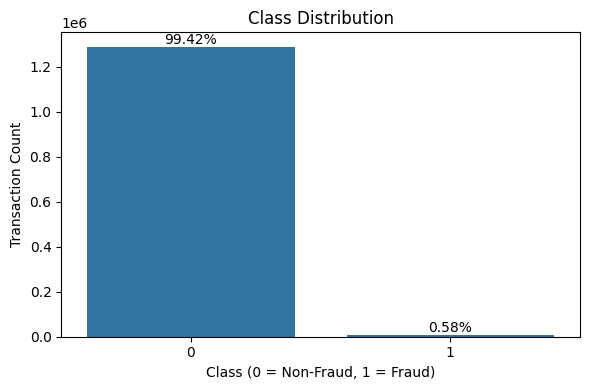

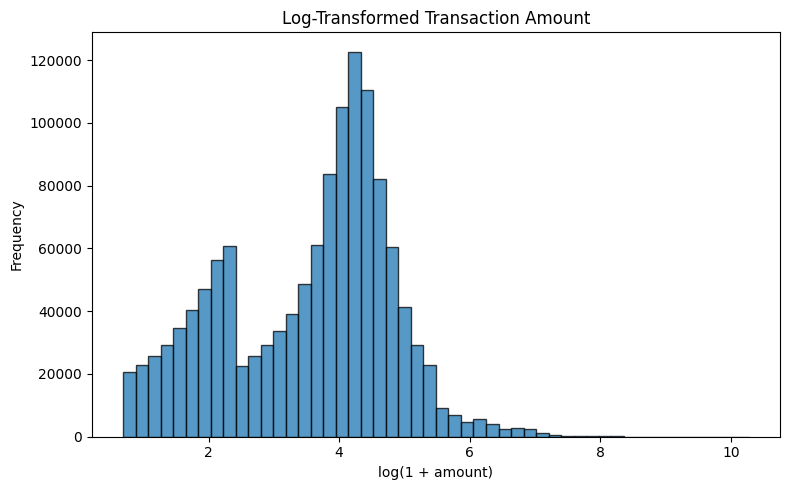

In [4]:
plt.figure(figsize=(6, 4))
ax = sns.countplot(x="is_fraud", data=train_df)
plt.title("Class Distribution")
plt.xlabel("Class (0 = Non-Fraud, 1 = Fraud)")
plt.ylabel("Transaction Count")

total = len(train_df)
for patch in ax.patches:
    height = patch.get_height()
    ax.text(
        patch.get_x() + patch.get_width() / 2,
        height,
        f"{100 * height / total:.2f}%",
        ha="center",
        va="bottom",
    )
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.hist(np.log1p(train_df["amt"]), bins=50, edgecolor="black", alpha=0.75)
plt.title("Log-Transformed Transaction Amount")
plt.xlabel("log(1 + amount)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


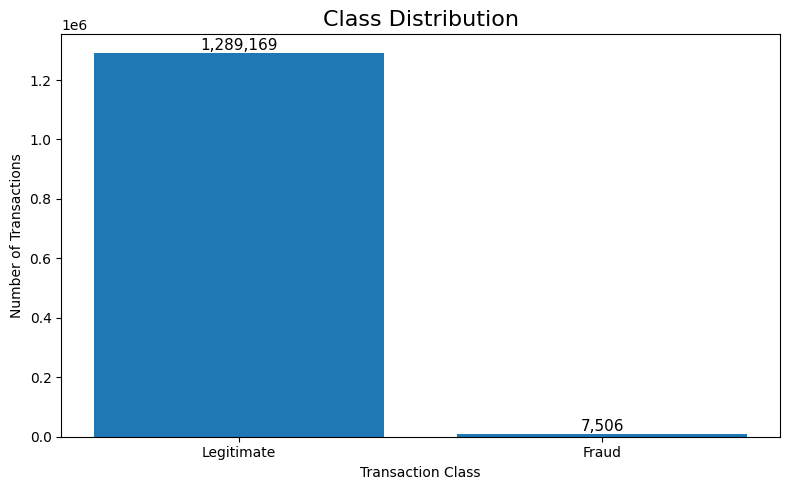

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

counts = train_df["is_fraud"].value_counts().sort_index()

bars = plt.bar(
    ["Legitimate", "Fraud"],
    counts.values
)

plt.title("Class Distribution", fontsize=16)
plt.xlabel("Transaction Class")
plt.ylabel("Number of Transactions")

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x()+bar.get_width()/2,
        height,
        f"{height:,}",
        ha="center",
        va="bottom",
        fontsize=11
    )

plt.tight_layout()

plt.savefig(
    "class_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 5. Feature engineering

In [5]:
def haversine_km(lat1, lon1, lat2, lon2):
    """Vectorized Haversine distance in kilometers."""
    lat1 = np.radians(lat1)
    lon1 = np.radians(lon1)
    lat2 = np.radians(lat2)
    lon2 = np.radians(lon2)

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = (
        np.sin(dlat / 2.0) ** 2
        + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2.0) ** 2
    )
    return 6371.0 * 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))


def clean_merchant_text(value: object) -> str:
    text = str(value).lower()
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    return re.sub(r"\s+", " ", text).strip()


SUSPICIOUS_WORDS = {
    "shop", "store", "travel", "jewel", "luxury",
    "transfer", "electronics", "wire", "gift", "cash", "market"
}


def add_non_target_features(df: pd.DataFrame, high_amount_cutoff: float) -> pd.DataFrame:
    """Create features that do not use target labels."""
    df = df.sort_values(["cc_num", "trans_date_trans_time"]).copy()

    # Temporal features
    dt = df["trans_date_trans_time"]
    df["trans_month"] = dt.dt.month
    df["trans_hour"] = dt.dt.hour
    df["trans_dayofweek"] = dt.dt.dayofweek
    df["trans_weekend"] = df["trans_dayofweek"].isin([5, 6]).astype(int)
    df["customer_age"] = dt.dt.year - df["dob"].dt.year

    # Amount and time flags
    df["amt_log"] = np.log1p(df["amt"])
    df["city_pop_log"] = np.log1p(df["city_pop"])
    df["high_amt_flag"] = (df["amt"] > high_amount_cutoff).astype(int)
    df["night_transaction"] = df["trans_hour"].isin([0, 1, 2, 3, 4]).astype(int)
    df["weekend_night"] = (
        (df["trans_weekend"] == 1) & (df["night_transaction"] == 1)
    ).astype(int)

    # Home-to-merchant distance
    df["distance_home_merchant_km"] = haversine_km(
        df["lat"], df["long"], df["merch_lat"], df["merch_long"]
    )

    # Previous transaction behavior
    grouped = df.groupby("cc_num", sort=False)
    prev_time = grouped["unix_time"].shift(1)
    prev_lat = grouped["merch_lat"].shift(1)
    prev_lon = grouped["merch_long"].shift(1)
    prev_amt = grouped["amt"].shift(1)

    df["time_since_prev_txn_sec"] = (df["unix_time"] - prev_time).fillna(-1)

    valid_previous = prev_lat.notna() & prev_lon.notna()
    df["distance_from_prev_txn_km"] = 0.0
    df.loc[valid_previous, "distance_from_prev_txn_km"] = haversine_km(
        prev_lat[valid_previous],
        prev_lon[valid_previous],
        df.loc[valid_previous, "merch_lat"],
        df.loc[valid_previous, "merch_long"],
    )

    valid_time = df["time_since_prev_txn_sec"] > 0
    df["speed_from_prev_kmph"] = 0.0
    df.loc[valid_time, "speed_from_prev_kmph"] = (
        df.loc[valid_time, "distance_from_prev_txn_km"]
        / (df.loc[valid_time, "time_since_prev_txn_sec"] / 3600.0)
    )

    df["impossible_travel_flag"] = (
        (df["distance_from_prev_txn_km"] > 500)
        & (df["time_since_prev_txn_sec"] > 0)
        & (df["time_since_prev_txn_sec"] < 3600)
    ).astype(int)

    df["amt_change_from_prev"] = (df["amt"] - prev_amt).fillna(0)

    # Frequency features
    df["cust_trans_count"] = df.groupby("cc_num")["cc_num"].transform("count")
    df["merchant_trans_count"] = df.groupby("merchant")["merchant"].transform("count")

    # Lightweight merchant text features
    df["merchant_clean"] = df["merchant"].map(clean_merchant_text)
    df["merchant_nlp_risk"] = df["merchant_clean"].map(
        lambda text: sum(word in text for word in SUSPICIOUS_WORDS)
    )
    df["merchant_name_length"] = df["merchant_clean"].str.len()
    df["merchant_word_count"] = df["merchant_clean"].str.split().str.len()

    return df


high_amount_cutoff = train_df["amt"].quantile(0.95)
train_df = add_non_target_features(train_df, high_amount_cutoff)
test_df = add_non_target_features(test_df, high_amount_cutoff)

print("Non-target feature engineering completed.")


Non-target feature engineering completed.


### Leakage-safe merchant and category risk encoding

The original notebook calculated merchant and category fraud rates from the full training set before cross-validation. The cleaned notebook uses out-of-fold target encoding for the training observations and full-training mappings only for the held-out test set. This avoids allowing a training row's own label to determine its encoded feature.

In [6]:
def add_oof_target_encoding(
    train: pd.DataFrame,
    test: pd.DataFrame,
    column: str,
    target: str = "is_fraud",
    n_splits: int = 5,
    smoothing: float = 20.0,
):
    train = train.copy()
    test = test.copy()

    encoded_column = f"{column}_risk"
    global_mean = train[target].mean()
    train[encoded_column] = np.nan

    splitter = StratifiedKFold(
        n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE
    )

    for fit_idx, valid_idx in splitter.split(train, train[target]):
        fit_part = train.iloc[fit_idx]
        valid_part = train.iloc[valid_idx]

        stats = fit_part.groupby(column)[target].agg(["mean", "count"])
        smoothed = (
            stats["mean"] * stats["count"] + global_mean * smoothing
        ) / (stats["count"] + smoothing)

        train.loc[train.index[valid_idx], encoded_column] = (
            valid_part[column].map(smoothed).fillna(global_mean).values
        )

    full_stats = train.groupby(column)[target].agg(["mean", "count"])
    full_smoothed = (
        full_stats["mean"] * full_stats["count"] + global_mean * smoothing
    ) / (full_stats["count"] + smoothing)

    test[encoded_column] = test[column].map(full_smoothed).fillna(global_mean)
    train[encoded_column] = train[encoded_column].fillna(global_mean)

    return train, test


train_df, test_df = add_oof_target_encoding(train_df, test_df, "merchant")
train_df, test_df = add_oof_target_encoding(train_df, test_df, "category")

print("Leakage-safe risk encoding completed.")


Leakage-safe risk encoding completed.


## 6. Final modeling dataset

In [7]:
FEATURES = [
    "amt",
    "amt_log",
    "high_amt_flag",
    "trans_hour",
    "trans_dayofweek",
    "trans_weekend",
    "trans_month",
    "night_transaction",
    "weekend_night",
    "customer_age",
    "distance_home_merchant_km",
    "city_pop_log",
    "time_since_prev_txn_sec",
    "distance_from_prev_txn_km",
    "speed_from_prev_kmph",
    "impossible_travel_flag",
    "amt_change_from_prev",
    "merchant_risk",
    "category_risk",
    "cust_trans_count",
    "merchant_trans_count",
    "merchant_nlp_risk",
    "merchant_name_length",
    "merchant_word_count",
]

TARGET = "is_fraud"

X_train = train_df[FEATURES].copy()
y_train = train_df[TARGET].copy()
X_test = test_df[FEATURES].copy()
y_test = test_df[TARGET].copy()

for frame in (X_train, X_test):
    frame.replace([np.inf, -np.inf], np.nan, inplace=True)

train_medians = X_train.median(numeric_only=True)
X_train = X_train.fillna(train_medians)
X_test = X_test.fillna(train_medians)

print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)
print("Missing values:", int(X_train.isna().sum().sum()), int(X_test.isna().sum().sum()))


X_train shape: (1296675, 24)
X_test shape : (555719, 24)
Missing values: 0 0


## 7. Model training

In [8]:
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

# Logistic Regression
lr_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )),
])

lr_cv_f1 = cross_val_score(
    lr_pipeline, X_train, y_train, cv=cv, scoring="f1", n_jobs=-1
)
lr_pipeline.fit(X_train, y_train)
y_pred_log = lr_pipeline.predict(X_test)
y_prob_log = lr_pipeline.predict_proba(X_test)[:, 1]

# Random Forest
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=8,
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
rf_cv_f1 = cross_val_score(
    clone(rf_model), X_train, y_train, cv=cv, scoring="f1", n_jobs=-1
)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

# Random Forest with leakage-safe SMOTE cross-validation
rf_smote_pipeline = ImbPipeline([
    ("smote", SMOTE(sampling_strategy=0.20, random_state=RANDOM_STATE)),
    ("model", RandomForestClassifier(
        n_estimators=20,
        max_depth=8,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )),
])
rf_smote_cv_f1 = cross_val_score(
    rf_smote_pipeline, X_train, y_train, cv=cv, scoring="f1", n_jobs=-1
)
rf_smote_pipeline.fit(X_train, y_train)
y_pred_smote = rf_smote_pipeline.predict(X_test)
y_prob_smote = rf_smote_pipeline.predict_proba(X_test)[:, 1]

print("Mean CV F1 — Logistic Regression:", lr_cv_f1.mean())
print("Mean CV F1 — Random Forest:", rf_cv_f1.mean())
print("Mean CV F1 — RF + SMOTE:", rf_smote_cv_f1.mean())


Mean CV F1 — Logistic Regression: 0.15852691104430663
Mean CV F1 — Random Forest: 0.38681176426840436
Mean CV F1 — RF + SMOTE: 0.559006683388334


### Tuned XGBoost

`RandomizedSearchCV` is used instead of a full grid search because the dataset is large. The scoring metric is binary F1, and stratified folds preserve the class distribution.

In [9]:
negative_count = int((y_train == 0).sum())
positive_count = int((y_train == 1).sum())
scale_pos_weight = negative_count / positive_count

xgb_base = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    scale_pos_weight=scale_pos_weight,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

parameter_distributions = {
    "n_estimators": [100, 150, 200],
    "max_depth": [3, 4, 5, 6],
    "learning_rate": [0.03, 0.05, 0.08, 0.10],
    "subsample": [0.7, 0.8, 0.9],
    "colsample_bytree": [0.7, 0.8, 0.9],
    "min_child_weight": [1, 3, 5],
    "gamma": [0, 0.1, 0.3],
    "reg_lambda": [1, 3, 5],
}

xgb_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=parameter_distributions,
    n_iter=10,
    scoring="f1",
    cv=cv,
    random_state=RANDOM_STATE,
    verbose=1,
    n_jobs=-1,
)

xgb_search.fit(X_train, y_train)
xgb_model = xgb_search.best_estimator_

y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

print("Best parameters:", xgb_search.best_params_)
print("Best CV F1:", xgb_search.best_score_)


Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best parameters: {'subsample': 0.8, 'reg_lambda': 5, 'n_estimators': 200, 'min_child_weight': 1, 'max_depth': 6, 'learning_rate': 0.08, 'gamma': 0.3, 'colsample_bytree': 0.9}
Best CV F1: 0.7192771886040337


## 8. Model evaluation

In [10]:
def evaluate_predictions(name, y_true, y_pred, y_prob):
    precision_curve, recall_curve, _ = precision_recall_curve(y_true, y_prob)
    return {
        "Model": name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "PR-AUC": auc(recall_curve, precision_curve),
        "ROC-AUC": roc_auc_score(y_true, y_prob),
    }


model_outputs = {
    "Logistic Regression": (y_pred_log, y_prob_log),
    "Random Forest": (y_pred_rf, y_prob_rf),
    "Random Forest + SMOTE": (y_pred_smote, y_prob_smote),
    "XGBoost": (y_pred_xgb, y_prob_xgb),
}

results = pd.DataFrame([
    evaluate_predictions(name, y_test, prediction, probability)
    for name, (prediction, probability) in model_outputs.items()
]).sort_values("F1", ascending=False)

display(results.round(4))


,Model,Accuracy,Precision,Recall,F1,PR-AUC,ROC-AUC
1,Random Forest,0.9854,0.1950,0.8928,0.3201,0.4706,0.9886
3,XGBoost,0.9826,0.1643,0.8587,0.2758,0.5350,0.9884
0,Logistic Regression,0.9445,0.0574,0.8676,0.1077,0.2389,0.9625
2,Random Forest + SMOTE,0.7712,0.0133,0.7963,0.0262,0.0737,0.8623


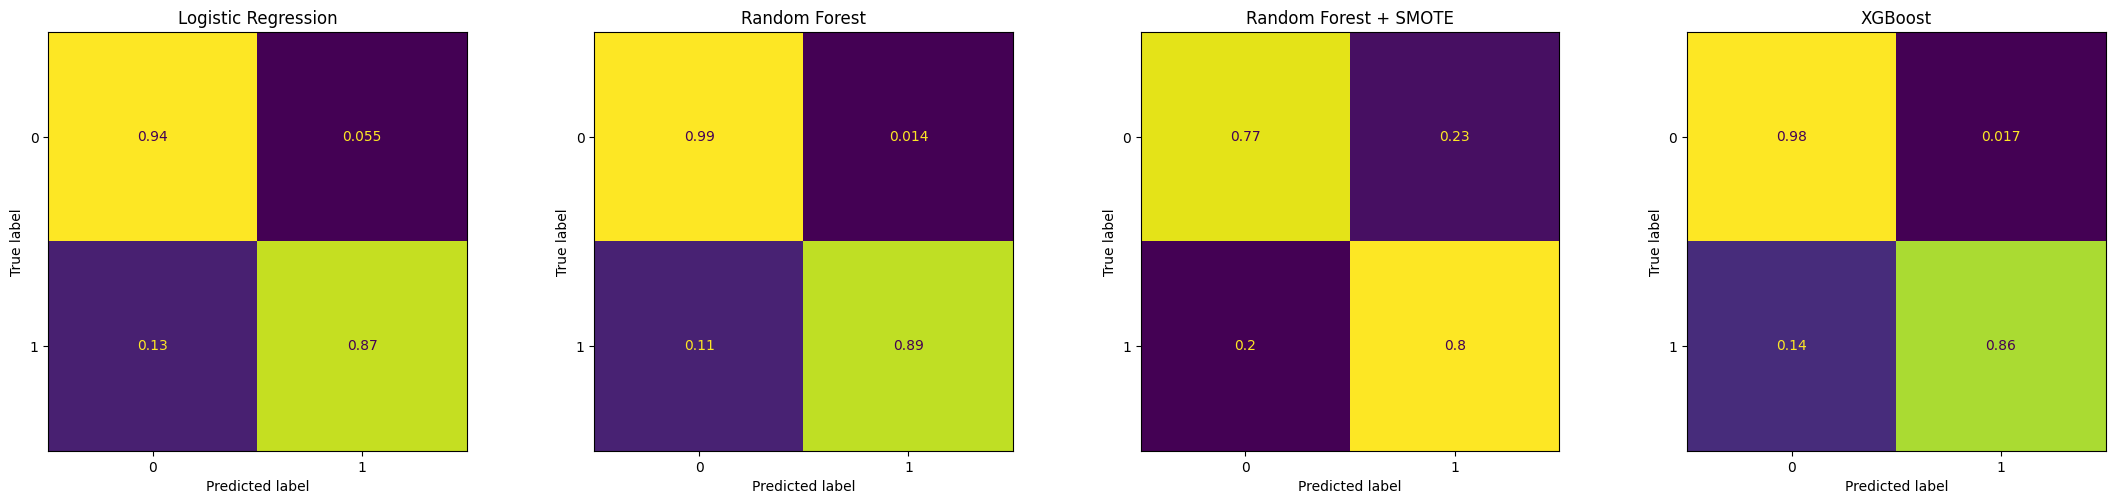

In [11]:
fig, axes = plt.subplots(1, 4, figsize=(22, 5))

for axis, (name, (prediction, _)) in zip(axes, model_outputs.items()):
    ConfusionMatrixDisplay.from_predictions(
        y_test,
        prediction,
        normalize="true",
        colorbar=False,
        ax=axis,
    )
    axis.set_title(name)

plt.tight_layout()
plt.show()


<Figure size 700x600 with 0 Axes>

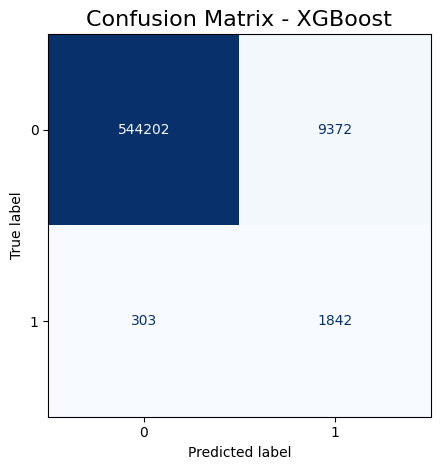

In [19]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

plt.figure(figsize=(7,6))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_xgb,
    cmap="Blues",
    colorbar=False,
    normalize=None
)

plt.title("Confusion Matrix - XGBoost", fontsize=16)

plt.tight_layout()

plt.savefig(
    "confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

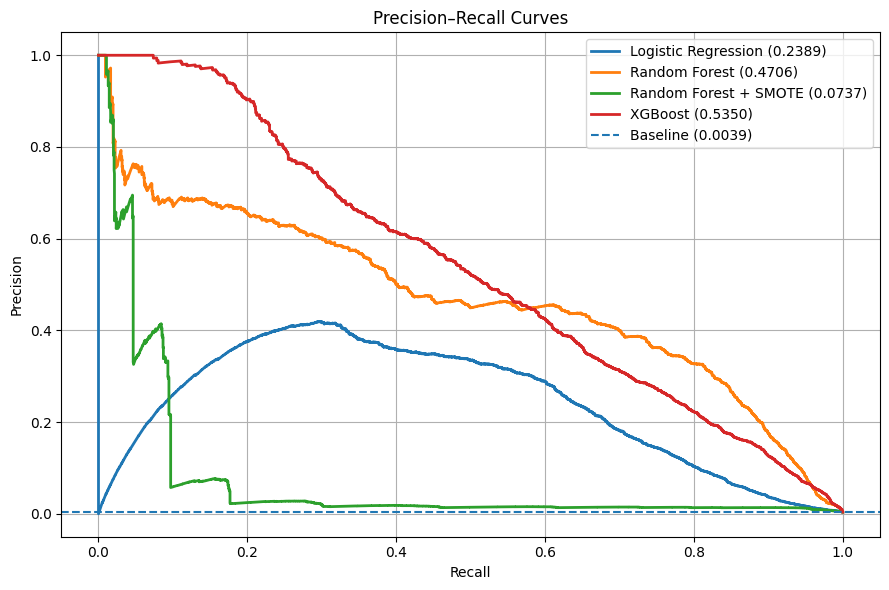

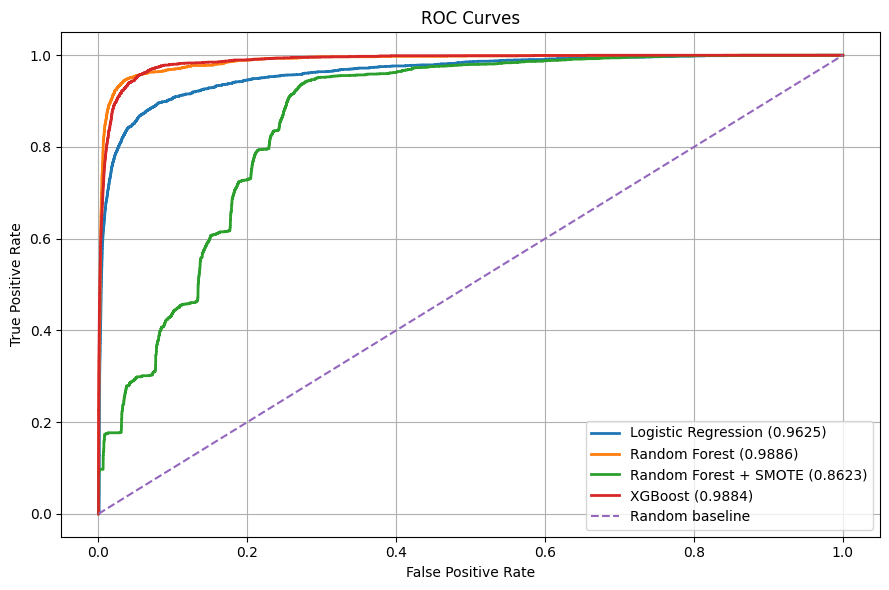

In [20]:
plt.figure(figsize=(9, 6))

for name, (_, probability) in model_outputs.items():
    precision_values, recall_values, _ = precision_recall_curve(y_test, probability)
    pr_auc = auc(recall_values, precision_values)
    plt.plot(recall_values, precision_values, linewidth=2, label=f"{name} ({pr_auc:.4f})")

baseline = y_test.mean()
plt.axhline(baseline, linestyle="--", label=f"Baseline ({baseline:.4f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curves")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig(
    "precision_recall_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

plt.figure(figsize=(9, 6))

for name, (_, probability) in model_outputs.items():
    false_positive_rate, true_positive_rate, _ = roc_curve(y_test, probability)
    roc_auc = roc_auc_score(y_test, probability)
    plt.plot(false_positive_rate, true_positive_rate, linewidth=2, label=f"{name} ({roc_auc:.4f})")

plt.plot([0, 1], [0, 1], linestyle="--", label="Random baseline")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend()
plt.grid(True)

plt.tight_layout()

plt.savefig(
    "roc_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()



## 9. XGBoost feature importance

The original notebook displayed Random Forest importance even though XGBoost was selected as the final model. The cleaned version reports importance from the selected XGBoost model.

,Feature,Importance
1,amt_log,0.4524
0,amt,0.1881
16,amt_change_from_prev,0.1275
18,category_risk,0.0465
3,trans_hour,0.0439
20,merchant_trans_count,0.0316
12,time_since_prev_txn_sec,0.0173
2,high_amt_flag,0.0148
9,customer_age,0.0105
7,night_transaction,0.0104


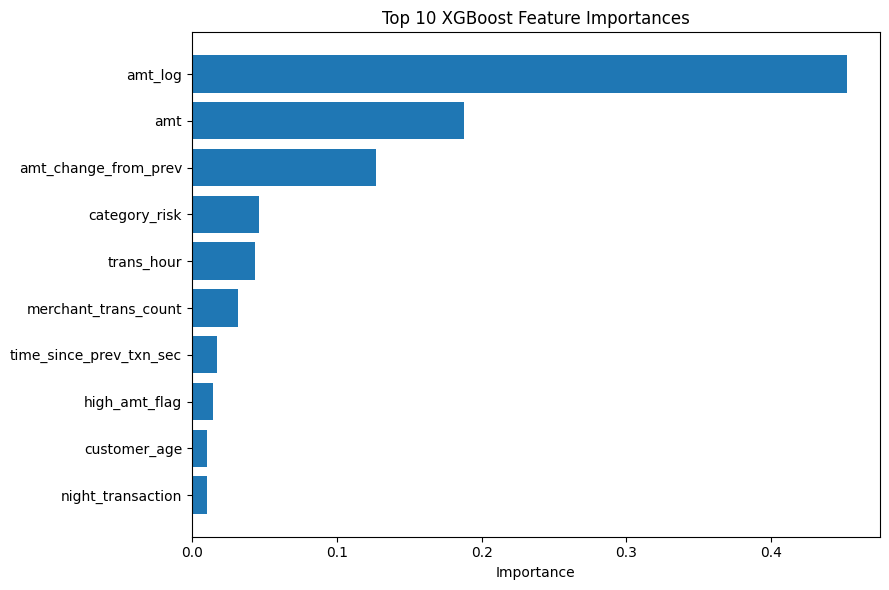

In [21]:
xgb_importance = pd.DataFrame({
    "Feature": FEATURES,
    "Importance": xgb_model.feature_importances_,
}).sort_values("Importance", ascending=False)

display(xgb_importance.head(15))

top_features = xgb_importance.head(10).sort_values("Importance")

plt.figure(figsize=(9, 6))
plt.barh(top_features["Feature"], top_features["Importance"])
plt.xlabel("Importance")
plt.title("Top 10 XGBoost Feature Importances")
plt.tight_layout()

plt.savefig(
    "feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 10. Cost-aware threshold evaluation

In [14]:
PRIMARY_FALSE_NEGATIVE_COST = 500
PRIMARY_FALSE_POSITIVE_COST = 10

def business_cost(y_true, y_pred, false_negative_cost, false_positive_cost):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return {
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp,
        "Business Cost ($)": fn * false_negative_cost + fp * false_positive_cost,
    }

cost_rows = []
for name, (prediction, _) in model_outputs.items():
    row = {"Approach": name}
    row.update(
        business_cost(
            y_test,
            prediction,
            PRIMARY_FALSE_NEGATIVE_COST,
            PRIMARY_FALSE_POSITIVE_COST,
        )
    )
    cost_rows.append(row)

cost_comparison = pd.DataFrame(cost_rows).sort_values("Business Cost ($)")
display(cost_comparison)


,Approach,TN,FP,FN,TP,Business Cost ($)
1,Random Forest,545670,7904,230,1915,194040
3,XGBoost,544202,9372,303,1842,245220
0,Logistic Regression,523027,30547,284,1861,447470
2,Random Forest + SMOTE,426870,126704,437,1708,1485540


### Amount-tiered rule threshold

The amount-tiered threshold is treated as a separate decision policy rather than a replacement for the model. Higher-value transactions receive lower fraud-probability thresholds.

In [15]:
test_amounts = X_test["amt"].to_numpy()

rule_thresholds = np.where(
    test_amounts >= 5000,
    0.50,
    np.where(
        test_amounts >= 1000,
        0.60,
        np.where(test_amounts >= 100, 0.75, 0.90),
    ),
)

y_pred_rule_threshold = (y_prob_xgb >= rule_thresholds).astype(int)

rule_metrics = evaluate_predictions(
    "XGBoost + Amount-Tiered Threshold",
    y_test,
    y_pred_rule_threshold,
    y_prob_xgb,
)
rule_metrics.update(
    business_cost(
        y_test,
        y_pred_rule_threshold,
        PRIMARY_FALSE_NEGATIVE_COST,
        PRIMARY_FALSE_POSITIVE_COST,
    )
)

display(pd.DataFrame([rule_metrics]).round(4))


,Model,Accuracy,Precision,Recall,F1,PR-AUC,ROC-AUC,TN,FP,FN,TP,Business Cost ($)
0,XGBoost + Amount-Tiered Threshold,0.9955,0.4476,0.7310,0.5552,0.5350,0.9884,551639,1935,577,1568,307850


,Model,Accuracy,Precision,Recall,F1 Score,PR-AUC,ROC-AUC
0,Logistic Regression,0.9445,0.0574,0.8676,0.1077,0.2391,0.9625
1,Random Forest,0.9854,0.1950,0.8928,0.3201,0.4708,0.9886
2,Random Forest + SMOTE,0.7712,0.0133,0.7963,0.0262,0.0739,0.8623
3,XGBoost,0.9826,0.1643,0.8587,0.2758,0.5351,0.9884
4,XGBoost + Amount-Tiered,0.9955,0.4476,0.7310,0.5552,0.5351,0.9884


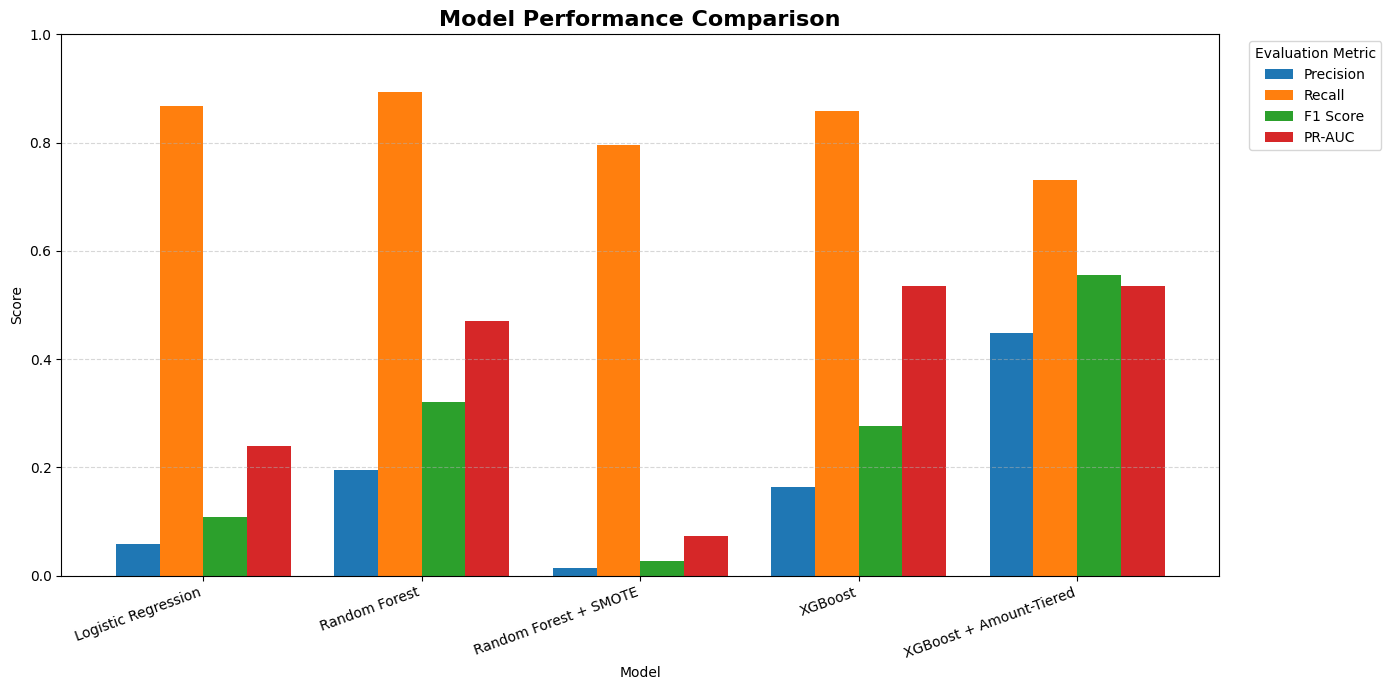

In [24]:
# ============================================================
# MODEL PERFORMANCE COMPARISON
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    average_precision_score,
    roc_auc_score,
)

# Store predictions and probabilities for all models
comparison_models = {
    "Logistic Regression": model_outputs["Logistic Regression"],
    "Random Forest": model_outputs["Random Forest"],
    "Random Forest + SMOTE": model_outputs["Random Forest + SMOTE"],
    "XGBoost": model_outputs["XGBoost"],
    "XGBoost + Amount-Tiered": (
        y_pred_rule_threshold,
        y_prob_xgb,
    ),
}

# Calculate evaluation metrics
comparison_results = []

for model_name, (predictions, probabilities) in comparison_models.items():

    comparison_results.append(
        {
            "Model": model_name,
            "Accuracy": accuracy_score(y_test, predictions),
            "Precision": precision_score(
                y_test,
                predictions,
                zero_division=0,
            ),
            "Recall": recall_score(
                y_test,
                predictions,
                zero_division=0,
            ),
            "F1 Score": f1_score(
                y_test,
                predictions,
                zero_division=0,
            ),
            "PR-AUC": average_precision_score(
                y_test,
                probabilities,
            ),
            "ROC-AUC": roc_auc_score(
                y_test,
                probabilities,
            ),
        }
    )

# Convert results into a DataFrame
model_comparison_df = pd.DataFrame(comparison_results)

# Display the complete results table
display(model_comparison_df.round(4))

# Select important metrics for visualization
plot_metrics = model_comparison_df.set_index("Model")[
    ["Precision", "Recall", "F1 Score", "PR-AUC"]
]

# Create the model comparison chart
ax = plot_metrics.plot(
    kind="bar",
    figsize=(14, 7),
    width=0.8,
)

plt.title(
    "Model Performance Comparison",
    fontsize=16,
    fontweight="bold",
)

plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1)

plt.xticks(
    rotation=20,
    ha="right",
)

plt.legend(
    title="Evaluation Metric",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.5,
)

plt.tight_layout()

# Save the figure for GitHub
plt.savefig(
    "model_comparison.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

In [23]:
print(model_outputs.keys())

dict_keys(['Logistic Regression', 'Random Forest', 'Random Forest + SMOTE', 'XGBoost'])


### BMR-inspired dynamic threshold sensitivity

This experiment uses a transaction-specific threshold:

\[
\tau(x) = \frac{C_{FP}}{C_{FP} + \max(\text{amount}, 0.01)}
\]

The false-positive cost is varied to show how decision policy changes. These sensitivity costs are reported separately from the project's primary `$500 FN / $10 FP` business-cost assumption.

In [16]:
def bmr_threshold(amount, false_positive_cost):
    return np.clip(
        false_positive_cost / (false_positive_cost + np.maximum(amount, 0.01)),
        0.01,
        0.99,
    )


sensitivity_rows = []
for false_positive_cost in [5, 10, 25, 50, 75, 100, 150, 200]:
    thresholds = bmr_threshold(test_amounts, false_positive_cost)
    prediction = (y_prob_xgb >= thresholds).astype(int)

    metrics = evaluate_predictions(
        f"BMR C_FP={false_positive_cost}",
        y_test,
        prediction,
        y_prob_xgb,
    )
    metrics.update(
        business_cost(
            y_test,
            prediction,
            PRIMARY_FALSE_NEGATIVE_COST,
            false_positive_cost,
        )
    )
    metrics["C_FP"] = false_positive_cost
    sensitivity_rows.append(metrics)

bmr_sensitivity = pd.DataFrame(sensitivity_rows).sort_values("Business Cost ($)")
display(bmr_sensitivity.round(4))


,Model,Accuracy,Precision,Recall,F1,PR-AUC,ROC-AUC,TN,FP,FN,TP,Business Cost ($),C_FP
0,BMR C_FP=5,0.9315,0.0526,0.9846,0.0998,0.5350,0.9884,515527,38047,33,2112,206735,5
1,BMR C_FP=10,0.9560,0.0790,0.9748,0.1462,0.5350,0.9884,529200,24374,54,2091,270740,10
2,BMR C_FP=25,0.9771,0.1402,0.9627,0.2448,0.5350,0.9884,540915,12659,80,2065,356475,25
3,BMR C_FP=50,0.9863,0.2121,0.9352,0.3458,0.5350,0.9884,546123,7451,139,2006,442050,50
4,BMR C_FP=75,0.9898,0.2640,0.9189,0.4102,0.5350,0.9884,548080,5494,174,1971,499050,75
5,BMR C_FP=100,0.9917,0.3042,0.9012,0.4548,0.5350,0.9884,549152,4422,212,1933,548200,100
6,BMR C_FP=150,0.9936,0.3617,0.8769,0.5122,0.5350,0.9884,550255,3319,264,1881,629850,150
7,BMR C_FP=200,0.9946,0.4057,0.8625,0.5518,0.5350,0.9884,550864,2710,295,1850,689500,200


## 11. Rule-based prediction explanations

In [17]:
def explain_transaction(row: pd.Series, probability: float) -> str:
    reasons = []

    if row["amt"] >= 5000:
        reasons.append("very high transaction amount")
    elif row["high_amt_flag"] == 1:
        reasons.append("unusually high transaction amount")

    if row["merchant_risk"] >= 0.02:
        reasons.append("elevated merchant fraud risk")

    if row["category_risk"] >= 0.02:
        reasons.append("elevated transaction-category risk")

    if row["impossible_travel_flag"] == 1:
        reasons.append("impossible geographic movement")

    if row["speed_from_prev_kmph"] > 500:
        reasons.append("abnormally high travel speed")

    if row["night_transaction"] == 1:
        reasons.append("late-night transaction")

    if not reasons:
        reasons.append("combined model pattern across multiple features")

    return (
        f"Fraud probability {probability:.3f}. "
        f"Flagged because of {', '.join(reasons)}."
    )


explanation_sample = X_test.copy()
explanation_sample["actual_label"] = y_test.to_numpy()
explanation_sample["predicted_label"] = y_pred_xgb
explanation_sample["fraud_probability"] = y_prob_xgb

flagged_cases = explanation_sample[
    explanation_sample["predicted_label"] == 1
].head(10).copy()

flagged_cases["explanation"] = flagged_cases.apply(
    lambda row: explain_transaction(row, row["fraud_probability"]),
    axis=1,
)

display(
    flagged_cases[
        [
            "amt",
            "merchant_risk",
            "category_risk",
            "speed_from_prev_kmph",
            "actual_label",
            "fraud_probability",
            "explanation",
        ]
    ]
)


,amt,merchant_risk,category_risk,speed_from_prev_kmph,actual_label,fraud_probability,explanation
33854,10.8700,0.0022,0.0025,65.5037,0,0.9384,Fraud probability 0.938. Flagged because of co...
91061,797.1000,0.0122,0.0145,12.6315,0,0.6298,Fraud probability 0.630. Flagged because of un...
93656,16.1100,0.0017,0.0021,49.4649,0,0.7051,Fraud probability 0.705. Flagged because of co...
125348,192.3100,0.0000,0.0016,127.4988,0,0.7011,Fraud probability 0.701. Flagged because of co...
140787,716.3200,0.0088,0.0072,103.7277,0,0.8463,Fraud probability 0.846. Flagged because of un...
179003,"1,128.9900",0.0065,0.0072,10.6959,0,0.7874,Fraud probability 0.787. Flagged because of un...
240803,16.6300,0.0028,0.0024,3.9127,0,0.7455,Fraud probability 0.746. Flagged because of co...
263627,50.2800,0.0019,0.0015,250.5055,0,0.8645,Fraud probability 0.864. Flagged because of co...
296835,23.8200,0.0005,0.0021,11.0614,0,0.9741,Fraud probability 0.974. Flagged because of co...
298184,702.8700,0.0114,0.0176,5.8183,0,0.9952,Fraud probability 0.995. Flagged because of un...


## 12. Reported results from the original project

The original completed run reported the following headline results:

| Model | Accuracy | Precision | Recall | F1 | Estimated Cost |
|---|---:|---:|---:|---:|---:|
| XGBoost | 0.9955 | 0.4586 | 0.9571 | 0.6201 | $70,240 |
| XGBoost + rule threshold | 0.9979 | 0.6690 | 0.9063 | 0.7697 | $110,120 |
| Random Forest | 0.9820 | 0.1675 | 0.9254 | 0.2837 | $178,660 |
| Random Forest + SMOTE | 0.9916 | 0.2899 | 0.8154 | 0.4277 | $240,840 |
| Logistic Regression | 0.9520 | 0.0651 | 0.8559 | 0.1210 | $418,090 |

Because this cleaned notebook uses leakage-safe target encoding, a fresh run may produce slightly different values. The new outputs should be treated as the authoritative reproducible results.


## 13. Conclusions

- Fraud detection requires imbalance-aware metrics; accuracy alone is insufficient.
- XGBoost provided the strongest precision–recall performance in the original study.
- Sequential, temporal, merchant-risk, and geospatial features add practical fraud signals.
- SMOTE can improve minority-class learning but may increase false alerts.
- Threshold choice should be separated from model training and evaluated against explicit business costs.
- Rule-based explanations provide transparent analyst-facing reasons without relying on an external generative-AI service.

## Repository guidance

Do not commit the full Kaggle CSV files. Keep them in a local `data/` folder and use `.gitignore` to exclude them.
